# VirtualiZarr → Icechunk in Cloud Storage (Source Coop)

This notebook creates an Icechunk store on Source Coop containing virtual references to Copernicus Marine Service chlorophyll data. The Icechunk store references the original Copernicus data rather than copying it.

## Key Points
- Virtual references point to Copernicus cloudferro S3/HTTPS URLs
- No data duplication - only metadata stored in Icechunk
- Source Coop provides cloud storage for the Icechunk repository
- Users can access the data from anywhere with proper Copernicus credentials

## Updating creds

```
/home/jovyan/.cargo/bin/source-coop login --duration 1d --port 8400
https://nmfs-openscapes.2i2c.cloud/user/eeholmes/proxy/8400/
```

In [1]:
!pip install -qU icechunk virtualizarr copernicusmarine xarray obstore obspec_utils

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xmip 0.7.2 requires cf_xarray>=0.6.0, which is not installed.
xmip 0.7.2 requires xarrayutils, which is not installed.
xmip 0.7.2 requires xgcm<0.7.0, which is not installed.


In [1]:
import warnings
import time
from pathlib import Path
import json

import xarray as xr
import icechunk
from obstore.store import from_url
from virtualizarr import open_virtual_dataset
from virtualizarr.parsers import HDFParser
from obspec_utils.registry import ObjectStoreRegistry

warnings.filterwarnings('ignore', category=UserWarning)
icechunk.__version__

'2.1.2'

## Full set of years

In [17]:
%%script false --no-raise
# Get file list for 1997 (example - adjust dates as needed)
!copernicusmarine get \
  --dataset-id cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D \
  --dataset-version 202603 \
  --filter "*.nc" \
  --create-file-list copernicus_files_all.txt

INFO - 2026-07-25T04:31:52Z - Selected dataset version: "202603"
INFO - 2026-07-25T04:31:52Z - Selected dataset part: "default"
INFO - 2026-07-25T04:31:52Z - Listing files on remote server...
11it [00:05,  1.98it/s]
{
  "number_of_files_to_download": 0,
  "status": "002",
  "message": "The request created a file list and then stopped."
}


In [2]:
# Read and convert URLs
with open('copernicus_files_all.txt', 'r') as f:
    s3_urls = [line.strip() for line in f if line.strip()]

s3_urls.sort()

COPERNICUS_ENDPOINT = "https://s3.waw3-1.cloudferro.com"
def s3_to_https(s3_url):
    if s3_url.startswith('s3://'):
        return f"{COPERNICUS_ENDPOINT}/{s3_url[5:]}"
    return s3_url

https_urls = [s3_to_https(url) for url in s3_urls]
print(f"Found {len(https_urls)} files")
print(f"First: {https_urls[0]}")
print(f"Last: {https_urls[-1]}")

Found 10490 files
First: https://s3.waw3-1.cloudferro.com/mdl-native-16/native/OCEANCOLOUR_GLO_BGC_L3_MY_009_103/cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D_202603/1997/09/19970904_cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D.nc
Last: https://s3.waw3-1.cloudferro.com/mdl-native-16/native/OCEANCOLOUR_GLO_BGC_L3_MY_009_103/cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D_202603/2026/07/20260717_cmems_obs-oc_glo_bgc-plankton_myint_l3-multi-4km_P1D.nc


In [9]:
# Create object-store handle for the REMOTE Copernicus files
url_prefix = f"{COPERNICUS_ENDPOINT}/"
store = from_url(url_prefix)
registry = ObjectStoreRegistry({url_prefix: store})
parser = HDFParser()

# Configure virtual chunk container
config = icechunk.RepositoryConfig.default()

# Split manifests every 100 time chunks.
config.manifest = icechunk.ManifestConfig(
    splitting=icechunk.ManifestSplittingConfig.from_dict(
        {
            icechunk.ManifestSplitCondition.AnyArray(): {
                icechunk.ManifestSplitDimCondition.DimensionName("time"): 100
            }
        }
    )
)
config.manifest.max_concurrent_manifest_fetches_during_commit = 16

# This tells Icechunk where the actual data chunks live
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=url_prefix,
        store=icechunk.http_store(),
    )
)

print(f"✓ Remote storage configured for: {url_prefix}")

✓ Remote storage configured for: https://s3.waw3-1.cloudferro.com/


In [4]:
import json
from pathlib import Path
import time
from datetime import datetime, timezone, timedelta

import icechunk


def _get_source_creds_expiration(
    creds_file,
    assumed_ttl_minutes=60,
):
    """
    Get expiration from the file modification time since json has no expiration
    """

    mtime = datetime.fromtimestamp(
        Path(creds_file).stat().st_mtime,
        tz=timezone.utc,
    )

    expiration = mtime + timedelta(minutes=assumed_ttl_minutes)
    return expiration

import json
import subprocess
from datetime import datetime
from pathlib import Path


def get_source_credentials(
    creds_file="/home/jovyan/.cache/source-coop/credentials/_default.json",
):
    # Ask the CLI to refresh its cached temporary credentials if needed.
    SOURCE_COOP_CLI = "/home/jovyan/.cargo/bin/source-coop"
    subprocess.run(
        [SOURCE_COOP_CLI, "creds"],
        check=True,
        stdout=subprocess.DEVNULL,
    )

    with Path(creds_file).open() as f:
        cached = json.load(f)

    expiration = datetime.fromisoformat(cached["expiration"])

    source_creds = {
        "aws_access_key_id": cached["access_key_id"],
        "aws_secret_access_key": cached["secret_access_key"],
        "aws_session_token": cached["session_token"],
        "region_name": "us-east-1",
        "endpoint_url": "https://data.source.coop",
    }

    return source_creds, expiration
    
def open_source_icechunk_repo(
    creds_file="globcolour-source-creds.json",
    bucket="fish-pace",
    prefix="globcolour/cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D",
    config=None,
    min_minutes_left=15,
    assumed_ttl_minutes=60,
    create_if_missing=True,
    verbose=True,
    check_expiration=True,
):
    """
    Open or create an Icechunk repo using Source Cooperative temporary credentials.

    If the creds file has no explicit expiration, estimate expiration from:
        file modification time + assumed_ttl_minutes

    If check_expiration=True, raises RuntimeError if less than min_minutes_left remain.
    """

#    creds_file = Path(creds_file)
#    with creds_file.open() as f:
#        source_creds = json.load(f)
#    expiration = _get_source_creds_expiration(
#        creds_file=creds_file,
#        assumed_ttl_minutes=assumed_ttl_minutes,
#    )

    source_creds, expiration = get_source_credentials()

    now = datetime.now(timezone.utc)
    time_left = expiration - now

    if check_expiration and time_left < timedelta(minutes=0):
        print(
            f"Stopping cleanly. Source credentials expired. "
            f"Refresh {creds_file} and set start_index."
        )
        return None, None, None, time_left

    storage = icechunk.s3_storage(
        bucket=bucket,
        prefix=prefix,
        region=source_creds["region_name"],
        endpoint_url=source_creds["endpoint_url"],
        force_path_style=True,
        access_key_id=source_creds["aws_access_key_id"],
        secret_access_key=source_creds["aws_secret_access_key"],
        session_token=source_creds["aws_session_token"],
    )

    if create_if_missing:
        try:
            repo = icechunk.Repository.create(storage, config)
            if verbose:
                print("Created new Icechunk repo")
        except Exception:
            repo = icechunk.Repository.open(storage, config=config)
            if verbose:
                print("Opened existing Icechunk repo")
    else:
        repo = icechunk.Repository.open(storage, config=config)
        if verbose:
            print("Opened existing Icechunk repo")

    if verbose:
        print(f"Time remaining on token: {time_left}")

    return repo, storage, source_creds, time_left

In [5]:
import time
from datetime import timedelta
from datetime import datetime
from pathlib import Path

from virtualizarr import open_virtual_dataset


def wait_for_fresh_repo(
    *,
    creds_file="globcolour-source-creds.json",
    min_minutes_left=15,
    config=None,
    verbose=True,
):
    while True:
        repo, storage, source_creds, time_left = open_source_icechunk_repo(
            creds_file=creds_file,
            create_if_missing=True,
            config=config,
            check_expiration=True,
            verbose=False,
        )

        if time_left >= timedelta(minutes=min_minutes_left):
            if verbose:
                print(f"Token okay. Time remaining: {time_left}")
            return repo, storage, source_creds, time_left

        print(
            f"Source credentials expire in about {time_left}. "
            f"Refresh {creds_file} before continuing."
        )

        try:
            answer = input(
                "Enter y after refreshing the token, or n to stop: "
            ).strip().lower()
        except KeyboardInterrupt:
            print("Input interrupted. Stopping cleanly.")
            return None, None, None, time_left

        if answer == "y":
            continue

        if answer == "n":
            print(
                "Stopping. Refresh the token and rerun starting "
                "at the last committed file."
            )
            return None, None, None, time_left

        print("Please enter y or n.")


def write_globcolour_to_icechunk(
    https_urls,
    *,
    commit_every=5,
    start_index=0,
    branch="main",
    group=None,
    config=None,  # required
    creds_file="globcolour-source-creds.json",
    min_minutes_left=15,
    parser=parser,
    registry=registry,
):
    """
    Virtualize GlobColour NetCDF files and append them along time.

    Parameters
    ----------
    https_urls
        Ordered list of GlobColour NetCDF URLs.
    commit_every
        Number of files per Icechunk commit.
    start_index
        Index of the first unprocessed URL. Use this to resume after stopping.
    branch
        Icechunk branch to write to.
    group
        Optional Zarr group within the Icechunk repository.
    config
        Icechunk RepositoryConfig, including the HTTP virtual chunk container.
    creds_file
        Source Cooperative temporary credentials JSON.
    min_minutes_left
        Require at least this much token lifetime before opening a new session.
    parser, registry
        VirtualiZarr parser and ObjectStoreRegistry.
    """
    if config is None:
        raise ValueError("config is required")

    total_added = start_index

    repo, storage, source_creds, time_left = wait_for_fresh_repo(
        creds_file=creds_file,
        min_minutes_left=min_minutes_left,
        config=config,
        verbose=False,
    )

    if repo is None:
        return total_added

    print(f"Token time remaining: {time_left}")

    session = repo.writable_session(branch)
    batch_start = time.perf_counter()
    files_in_batch = 0

    for i, url in enumerate(
        https_urls[start_index:],
        start=start_index,
    ):
        filename = Path(url).name

        print(
            f"[{datetime.now():%H:%M:%S}] "
            f"[{i + 1}/{len(https_urls)}] Processing {filename}..."
        )

        t0 = time.perf_counter()

        # GlobColour files already contain their time coordinate.
        vds = open_virtual_dataset(
            url=url,
            parser=parser,
            registry=registry,
            loadable_variables=[
                "time",
                "lat",
                "lon",
                "latitude",
                "longitude",
            ],
            decode_times=True,
        )

        write_kwargs = {}

        if group is not None:
            write_kwargs["group"] = group

        open_elapsed = time.perf_counter() - t0
        t0 = time.perf_counter()

        # Create the hierarchy for the first file in the complete dataset.
        # Every later file appends along the existing time dimension.
        if total_added == 0:
            vds.virtualize.to_icechunk(
                session.store,
                **write_kwargs,
            )
        else:
            vds.virtualize.to_icechunk(
                session.store,
                append_dim="time",
                **write_kwargs,
            )
            
        append_elapsed = time.perf_counter() - t0

        total_added += 1
        files_in_batch += 1

        print(
            f"    open: {open_elapsed:.2f}s | "
            f"append: {append_elapsed:.2f}s"
        )


        if files_in_batch == commit_every:
            elapsed = time.perf_counter() - batch_start

            snapshot_id = session.commit(
                f"Add through file {i + 1}"
            )

            print(
                f"Committed through file {i + 1} "
                f"({total_added} total files) in {elapsed:.2f} seconds. "
                f"Snapshot: {snapshot_id}"
            )

            # Reopen the repository with a fresh token if necessary.
            repo, storage, source_creds, time_left = wait_for_fresh_repo(
                creds_file=creds_file,
                min_minutes_left=min_minutes_left,
                config=config,
                verbose=False,
            )

            if repo is None:
                print(
                    f"Stopped after file {i + 1}. "
                    f"Resume with start_index={total_added}."
                )
                return total_added

            print(f"Token time remaining: {time_left}")

            session = repo.writable_session(branch)
            batch_start = time.perf_counter()
            files_in_batch = 0

    # Commit the final partial batch.
    if files_in_batch > 0:
        elapsed = time.perf_counter() - batch_start

        snapshot_id = session.commit(
            f"Add through file {total_added}"
        )

        print(
            f"Final commit through file {total_added} "
            f"in {elapsed:.2f} seconds. "
            f"Snapshot: {snapshot_id}"
        )

    print(
        f"\n✓ Successfully added {total_added - start_index} new files "
        f"({total_added} total files processed)"
    )

    return total_added

In [7]:
total_added = write_globcolour_to_icechunk(
    https_urls,
    commit_every=20,
    start_index=10490,
    config=config,
    creds_file="globcolour-source-creds.json",
    min_minutes_left=10
)

Token time remaining: 4:55:20.258748

✓ Successfully added 0 new files (10490 total files processed)


## Tag the final and clean-up

In [13]:
repo, storage, source_creds, time_left = open_source_icechunk_repo()

Opened existing Icechunk repo
Time remaining on token: 4:51:19.863616


In [16]:
# Final commit has already happened.
final_snapshot_id = repo.lookup_branch("main")
final_snapshot = repo.lookup_snapshot(final_snapshot_id)
cutoff = final_snapshot.written_at
tag_id = "2026-07-17"

print(final_snapshot.id)
print(final_snapshot.written_at)

tags = repo.list_tags()

if tag_id not in tags:
    repo.create_tag(
        tag_id,  # last day represented by the files
        final_snapshot.id,
    )

expired = repo.expire_snapshots(
    older_than=cutoff,
    delete_expired_tags=False,
    delete_expired_branches=False,
)

print("Snapshots marked expired:", len(expired))

# Verify the protected references before permanently deleting objects.
print("main:", repo.lookup_branch("main"))
print("tag:", repo.lookup_tag(tag_id))

assert repo.lookup_branch("main") == final_snapshot.id
assert repo.lookup_tag(tag_id) == final_snapshot.id


XFCYPQZGPCYSPQ4WDNV0
2026-08-07 22:47:34.813658+00:00
Snapshots marked expired: 0
main: XFCYPQZGPCYSPQ4WDNV0
tag: XFCYPQZGPCYSPQ4WDNV0


In [17]:
gc_result = repo.garbage_collect(cutoff)

print(gc_result)

  2026-08-08T00:50:39.100193Z  WARN icechunk_storage::storage: ignoring error in Storage::delete_batch
    at icechunk-storage/src/storage.rs:605

  2026-08-08T00:50:39.478396Z  WARN icechunk_storage::storage: ignoring error in Storage::delete_batch
    at icechunk-storage/src/storage.rs:605

  2026-08-08T00:50:39.662208Z  WARN icechunk_storage::storage: ignoring error in Storage::delete_batch
    at icechunk-storage/src/storage.rs:605

  2026-08-08T00:50:39.861013Z  WARN icechunk_storage::storage: ignoring error in Storage::delete_batch
    at icechunk-storage/src/storage.rs:605

  2026-08-08T00:50:40.019009Z  WARN icechunk_storage::storage: ignoring error in Storage::delete_batch
    at icechunk-storage/src/storage.rs:605

  2026-08-08T00:50:40.321814Z  WARN icechunk_storage::storage: ignoring error in Storage::delete_batch
    at icechunk-storage/src/storage.rs:605

  2026-08-08T00:50:40.445861Z  WARN icechunk_storage::storage: ignoring error in Storage::delete_batch
    at icechunk

<icechunk.ops.GCSummary>
bytes_deleted: 0
chunks_deleted: 0
manifests_deleted: 0
snapshots_deleted: 0
attributes_deleted: 0
transaction_logs_deleted: 0



  2026-08-08T00:50:44.444624Z  WARN icechunk_storage::storage: ignoring error in Storage::delete_batch
    at icechunk-storage/src/storage.rs:605

  2026-08-08T00:50:44.488313Z  WARN icechunk_storage::storage: ignoring error in Storage::delete_batch
    at icechunk-storage/src/storage.rs:605

  2026-08-08T00:50:44.494254Z  WARN icechunk_storage::storage: ignoring error in Storage::delete_batch
    at icechunk-storage/src/storage.rs:605



## Add readme and notebooks

In [ ]:
# Upload files
import json
from pathlib import Path

import boto3

bucket = "fish-pace"
prefix = (
    "globcolour"
)

with open("globcolour-source-creds.json") as f:
    source_creds = json.load(f)

s3 = boto3.client(
    "s3",
    endpoint_url=source_creds["endpoint_url"],
    region_name=source_creds["region_name"],
    aws_access_key_id=source_creds["aws_access_key_id"],
    aws_secret_access_key=source_creds["aws_secret_access_key"],
    aws_session_token=source_creds.get("aws_session_token"),
)

files_to_upload = [
    "README.md",
    "copernicus-icechunk-sc.ipynb",
    "environment.yml",
]

for local_file in files_to_upload:
    path = Path(local_file)

    if not path.is_file():
        raise FileNotFoundError(f"File not found: {path}")

    key = f"{prefix}/{path.name}"

    s3.upload_file(
        Filename=str(path),
        Bucket=bucket,
        Key=key,
    )

    print(
        f"Uploaded {path} -> "
        f"s3://{bucket}/{key}"
    )

## Read in the icechunk

✓ Created Icechunk repository on Source Coop
✓ Stored virtual references to Copernicus cloudferro data
✓ No data duplication - only metadata in Icechunk


In [6]:
import icechunk as ic # need icechunk > 2
import xarray as xr

url = "https://data.source.coop/fish-pace/globcolour/cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D"
storage = ic.http_storage(url)
repo = ic.Repository.open(storage)
auth = {p: ic.credentials.HttpAccess for p in repo.config.virtual_chunk_containers or []}
store = repo.reopen(authorize_virtual_chunk_access=auth).readonly_session("main").store

# Use create_default_indexes=False, if https access slow (in EU say)
ds = xr.open_zarr(store, consolidated=False, chunks=None)
ds

<xarray.Dataset> Size: 47TB
Dimensions:              (time: 10490, lat: 4320, lon: 8640)
Coordinates:
  * time                 (time) datetime64[ns] 84kB 1997-09-04 ... 2026-07-17
  * lat                  (lat) float32 17kB 89.98 89.94 89.9 ... -89.94 -89.98
  * lon                  (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 180.0
Data variables: (12/21)
    CHL                  (time, lat, lon) float32 2TB ...
    CHL_uncertainty      (time, lat, lon) float64 3TB ...
    DIATO_uncertainty    (time, lat, lon) float64 3TB ...
    DIATO                (time, lat, lon) float32 2TB ...
    DINO_uncertainty     (time, lat, lon) float64 3TB ...
    HAPTO                (time, lat, lon) float32 2TB ...
    ...                   ...
    PROKAR               (time, lat, lon) float32 2TB ...
    PICO_uncertainty     (time, lat, lon) float64 3TB ...
    NANO_uncertainty     (time, lat, lon) float64 3TB ...
    PROCHLO              (time, lat, lon) float32 2TB ...
    PROCHLO_uncertainty  (time, lat, lon) float64 3TB ...
    PROKAR_uncertainty   (time, lat, lon) float64 3TB ...
Attributes: (12/91)
    lon_step:                        0.0416666679084301
    keywords:                        EARTH SCIENCE > OCEANS > OCEAN CHEMISTRY...
    cmems_product_id:                OCEANCOLOUR_GLO_BGC_L3_MY_009_103
    lat_step:                        0.0416666679084301
    grid_mapping:                    Equirectangular
    title:                           cmems_obs-oc_glo_bgc-plankton_my_l3-mult...
    ...                              ...
    contact:                         servicedesk.cmems@acri-st.fr
    westernmost_longitude:           -180.0
    geospatial_vertical_positive:    up
    date_created:                    2026-07-25T02:30:42Z
    nb_valid_bins:                   10024612
    pct_valid_bins:                  26.857778206447186

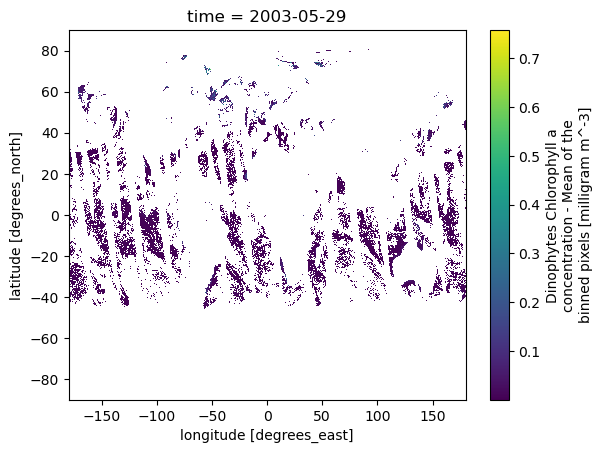

In [14]:
ds.sel(time="2003-05-29").DINO.plot()

## Troubleshooting

In [10]:
# List everything
import boto3
import json

with open("globcolour-source-creds.json") as f:
    creds = json.load(f)

s3 = boto3.client(
    "s3",
    endpoint_url=creds["endpoint_url"],
    region_name=creds["region_name"],
    aws_access_key_id=creds["aws_access_key_id"],
    aws_secret_access_key=creds["aws_secret_access_key"],
    aws_session_token=creds["aws_session_token"],
)

bucket = "fish-pace"
prefix = "globcolour/"
DRY_RUN = True

paginator = s3.get_paginator("list_objects_v2")

keys = []

for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
    for obj in page.get("Contents", []):
        keys.append(obj["Key"])
        print(f'{obj["Size"]:>12,}  {obj["Key"]}')

print(f"\nFound {len(keys):,} objects under s3://{bucket}/{prefix}")


Found 0 objects under s3://fish-pace/globcolour/


In [13]:
%%script false --no-raise
# Delete everything
import json
import boto3

with open("globcolour-source-creds.json") as f:
    source_creds = json.load(f)

bucket = "fish-pace"
prefix = "globcolour/cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D"

s3 = boto3.client(
    "s3",
    endpoint_url=source_creds["endpoint_url"],
    region_name=source_creds["region_name"],
    aws_access_key_id=source_creds["aws_access_key_id"],
    aws_secret_access_key=source_creds["aws_secret_access_key"],
    aws_session_token=source_creds["aws_session_token"],
)

def delete_s3_prefix(bucket, prefix):
    prefix = prefix.strip("/") + "/"

    paginator = s3.get_paginator("list_objects_v2")

    # Gather keys first so changing the listing while paginating
    # does not cause objects to be skipped.
    keys = []

    for page in paginator.paginate(
        Bucket=bucket,
        Prefix=prefix,
    ):
        keys.extend(
            obj["Key"]
            for obj in page.get("Contents", [])
        )

    print(f"Found {len(keys)} objects under s3://{bucket}/{prefix}")

    for i, key in enumerate(keys, start=1):
        s3.delete_object(
            Bucket=bucket,
            Key=key,
        )

        if i % 100 == 0 or i == len(keys):
            print(f"Deleted {i} of {len(keys)} objects")

    print(f"Deleted everything under s3://{bucket}/{prefix}")


delete_s3_prefix(bucket, prefix)

Found 360 objects under s3://fish-pace/globcolour/cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D/
Deleted 100 of 360 objects
Deleted 200 of 360 objects
Deleted 300 of 360 objects
Deleted 360 of 360 objects
Deleted everything under s3://fish-pace/globcolour/cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D/


In [14]:
# Check it is indeed empty
response = s3.list_objects_v2(
    Bucket="fish-pace",
    Prefix="globcolour/cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D",
    MaxKeys=10,
)

print(response.get("Contents", []))

[]


In [19]:
# List everything
import boto3
import json

with open("globcolour-source-creds.json") as f:
    creds = json.load(f)

s3 = boto3.client(
    "s3",
    endpoint_url=creds["endpoint_url"],
    region_name=creds["region_name"],
    aws_access_key_id=creds["aws_access_key_id"],
    aws_secret_access_key=creds["aws_secret_access_key"],
    aws_session_token=creds["aws_session_token"],
)

def prefix_size_gb(s3, bucket, prefix):
    total_bytes = 0
    object_count = 0

    paginator = s3.get_paginator("list_objects_v2")

    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            total_bytes += obj["Size"]
            object_count += 1

    return object_count, total_bytes / 1024**3


n_objects, size_gb = prefix_size_gb(
    s3,
    bucket="fish-pace",
    prefix="globcolour/cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D",
)

print(f"{n_objects:,} objects")
print(f"{size_gb:.2f} GiB")

ImportError: cannot import name 'DocumentModifiedShape' from 'botocore.docs.utils' (/srv/conda/envs/notebook/lib/python3.12/site-packages/botocore/docs/utils.py)